In [317]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
from torch import nn

import warnings
warnings.filterwarnings("ignore")

In [318]:
# Data: https://github.com/atilsamancioglu/DeepLearningBootcamp/blob/main/08-email_classification_svm.csv

df = pd.read_csv("08-email_classification_svm.csv")
print(df.shape)
df.head()

(1000, 3)


,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


In [319]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [320]:
# E-posta Sınıflandırması (İş vs Kişisel)
# subject_formality_score -> Konu satırının resmiyet düzeyine göre verilen puan
# sender_relationship_score -> Gönderenin ne kadar tanıdık/yakın olduğunu temsil eden puan
# email_type -> 0 = Kişisel, 1 = İş e-postası

<function matplotlib.pyplot.show(close=None, block=None)>

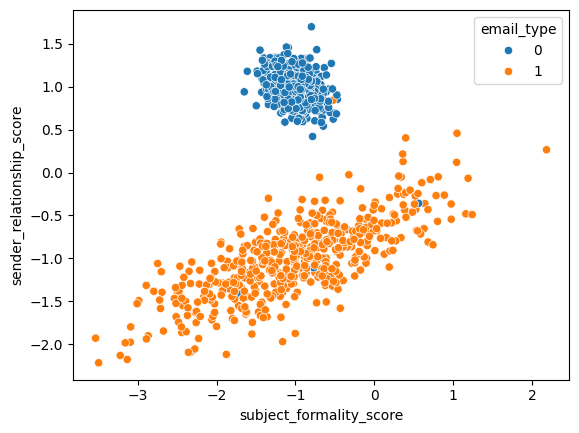

In [321]:
sns.scatterplot(data=df, x="subject_formality_score", y="sender_relationship_score", hue="email_type")
plt.show

In [322]:
X = df[['subject_formality_score', 'sender_relationship_score']].values
y = df["email_type"].values

In [323]:
X

array([[-1.49678965,  0.77925822],
       [-1.21760978,  0.88960104],
       [-0.37594518, -0.82332435],
       ...,
       [-1.36975007,  1.0222785 ],
       [-1.1850392 , -1.20266647],
       [-1.17835511,  1.08298346]])

In [324]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [325]:
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [326]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [327]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


In [328]:
# y_train başlangıçta (800,) şeklinde tek boyutlu bir tensor
# ancak PyTorch'ta birçok loss fonksiyonu (örn: BCELoss, BCEWithLogitsLoss)
# model çıktısını (N, 1) formatında bekler

# unsqueeze(1) -> 1. eksene yeni bir boyut ekler
# yani (800,) -> (800, 1) olur
# bu sayede model çıktısı ile hedef tensor aynı shape'e gelir

In [329]:
class Classification(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2, out_features=5)
    self.layer_2 = nn.Linear(in_features=5, out_features=1)

  def forward(self, x: torch.Tensor) -> torch.Tensor:
    return self.layer_2(self.layer_1(x))

In [330]:
model_0 = Classification()

In [331]:
# Loss fonksiyonu
loss_fn = nn.BCEWithLogitsLoss()
# loss_fn = nn.BCELoss()

# BCEWithLogitsLoss:
# - Binary Classification (ikili sınıflandırma) için kullanılır
# - İçerisinde hem Sigmoid aktivasyonunu hem de Binary Cross Entropy (BCE) loss'u birlikte barındırır
# - Yani model çıktısına ayrıca sigmoid uygulamana gerek yoktur
# - Sayısal olarak daha stabil çalışır (özellikle büyük/çok küçük değerlerde)
# - Model çıktısı (logits) direkt olarak bu loss'a verilir
# Örnek: model output -> raw değer (ör: -2.3, 1.7, vs.)
# loss_fn bu değeri önce sigmoid'e sokar, sonra BCE hesaplar

# BCELoss:
# - Yine binary classification için kullanılır
# - Ancak bu loss fonksiyonunu kullanmadan önce model çıktısına manuel olarak sigmoid uygulanmalıdır
# - Yani modelin son katmanında sigmoid olmalı ya da forward sonrası sigmoid çağırmalısın
# - BCEWithLogitsLoss'a göre daha az stabil olabilir

# Örnek: output = torch.sigmoid(model(X))
# loss = nn.BCELoss()(output, y)


# Özet fark:
# BCEWithLogitsLoss -> Sigmoid + BCE (tek adımda, daha stabil)
# BCELoss           -> Önce sigmoid sen uygularsın, sonra loss hesaplanır

In [332]:
# optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [333]:
# Doğruluk (accuracy) hesaplama.
# Accuracy hesaplamak için torchmetrics kullanılabilir, ancak şimdilik manuel yapıyoruz
def calculate_accuracy(y_test, y_pred):

    # torch.eq() iki tensorün eşit olduğu durumları hesaplar (eleman bazlı karşılaştırma yapar)
    correct = torch.eq(y_test, y_pred).sum().item()

    # Doğruluk oranı = doğru tahmin sayısı / toplam tahmin sayısı
    accuracy = (correct / len(y_pred)) * 100

    return accuracy

In [334]:
# Logit ve sigmoid fonksiyonlarını anlamak için, eğitim yapılmadan elde edilen tahminlere bakalım.
# İlk 5 tahmini görüntüle
y_logits = model_0(X_test)[:5]
y_logits

tensor([[-0.1342],
        [-0.2908],
        [-0.1631],
        [-0.2298],
        [-0.1364]], grad_fn=<SliceBackward0>)

In [335]:
# Peki bunların 0 mı yoksa 1 mi olduğuna nasıl karar vereceğiz? Kişisel mi yoksa işle ilgili mi? Bunları anlamlandırmak için sigmoid fonksiyonuna ihtiyacımız var.
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4665],
        [0.4278],
        [0.4593],
        [0.4428],
        [0.4660]], grad_fn=<SigmoidBackward0>)

In [336]:
# Modelden ham çıktıları (logits) alıyoruz
# Bunlar henüz olasılık değil, -∞ ile +∞ arasında değerlerdir

# Sigmoid fonksiyonu uygulayarak logits -> olasılığa çeviriyoruz
# Çıktılar artık 0 ile 1 arasında (binary classification için)
# 0'a yakın -> sınıf 0, 1'e yakın -> sınıf 1 anlamına gelir

# Örnek:
# 0.29 -> sınıf 0'a daha yakın
# 0.42 -> hala sınıf 0 (genelde threshold = 0.5 kullanılır)

In [337]:
# Eğer 0,5'in üzerindeyse 1, 0'ın altındaysa 0 diyebiliriz.
y_preds = torch.round(y_pred_probs)
y_preds

tensor([[0.],
        [0.],
        [0.],
        [0.],
        [0.]], grad_fn=<RoundBackward0>)

In [338]:
y_test[:5]

tensor([[0.],
        [1.],
        [0.],
        [1.],
        [0.]])

In [339]:
calculate_accuracy(y_test[:5], y_preds)

60.0

In [340]:
# Model henüz eğitilmeden sadece forward + sigmoid mantığı ile çıktı üretildi
# Sigmoid sonrası değerler 0.5 eşik değeri kullanılarak 0 veya 1 sınıfına çevrildi
# Gerçek etiketlerle karşılaştırılarak küçük bir örnek üzerinde doğruluk hesaplandı
# Bu sonuç model eğitilmediği için rastgeleye yakın bir performansı temsil eder

In [341]:
# Model Eğitimi

torch.manual_seed(42)
epochs = 100

for epoch in range(epochs):
    # Eğitim modu açılır (model öğrenmeye başlar)
    model_0.train()

    # Forward pass: model ham çıktı üretir (logits)
    y_logits = model_0(X_train)

    # Logits -> sigmoid -> olasılık -> 0.5 eşik ile sınıf tahmini
    y_pred = torch.round(torch.sigmoid(y_logits))

    # Loss hesaplanır (BCEWithLogitsLoss = sigmoid + loss birlikte)
    loss = loss_fn(y_logits, y_train)

    # Eğitim doğruluğu hesaplanır
    acc = calculate_accuracy(y_test=y_train, y_pred=y_pred)

    # Gradientler sıfırlanır (önceki iterasyon birikmesin)
    optimizer.zero_grad()

    # Backpropagation (hata geriye yayılır)
    loss.backward()

    # Ağırlıklar güncellenir
    optimizer.step()

    ### TEST AŞAMASI ###
    model_0.eval()

    with torch.inference_mode():
        # Test verisi için forward pass
        test_logits = model_0(X_test)

        # Test tahmini (sigmoid + threshold)
        test_pred = torch.round(torch.sigmoid(test_logits))

        # Test loss hesaplanır
        test_loss = loss_fn(test_logits, y_test)

        # Test doğruluğu hesaplanır
        test_acc = calculate_accuracy(y_test=y_test, y_pred=test_pred)

    # Her 5 epoch'ta sonuç yazdırılır
    if epoch % 5 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.72349, Accuracy: 49.75% | Test loss: 0.71765, Test acc: 52.00%
Epoch: 5 | Loss: 0.70700, Accuracy: 49.75% | Test loss: 0.70068, Test acc: 52.00%
Epoch: 10 | Loss: 0.69118, Accuracy: 49.75% | Test loss: 0.68440, Test acc: 52.00%
Epoch: 15 | Loss: 0.67597, Accuracy: 49.75% | Test loss: 0.66874, Test acc: 52.00%
Epoch: 20 | Loss: 0.66130, Accuracy: 49.75% | Test loss: 0.65364, Test acc: 52.00%
Epoch: 25 | Loss: 0.64712, Accuracy: 49.75% | Test loss: 0.63904, Test acc: 52.00%
Epoch: 30 | Loss: 0.63337, Accuracy: 50.12% | Test loss: 0.62490, Test acc: 52.00%
Epoch: 35 | Loss: 0.62002, Accuracy: 52.62% | Test loss: 0.61117, Test acc: 54.00%
Epoch: 40 | Loss: 0.60702, Accuracy: 58.63% | Test loss: 0.59780, Test acc: 63.50%
Epoch: 45 | Loss: 0.59435, Accuracy: 64.50% | Test loss: 0.58478, Test acc: 70.50%
Epoch: 50 | Loss: 0.58198, Accuracy: 70.62% | Test loss: 0.57207, Test acc: 76.50%
Epoch: 55 | Loss: 0.56988, Accuracy: 76.75% | Test loss: 0.55965, Test acc: 81.50%
Epoch:

In [342]:
import numpy as np
def plot_linear_decision_boundary(model, X, y):

    # layer_1: (5,2)
    # layer_2: (1,5)
    # toplam efektif ağırlık = layer_2.weight @ layer_1.weight = (1,2)
    W1 = model.layer_1.weight.detach().numpy()       # shape (5,2)
    b1 = model.layer_1.bias.detach().numpy()         # shape (5,)
    W2 = model.layer_2.weight.detach().numpy()       # shape (1,5)
    b2 = model.layer_2.bias.detach().numpy()[0]      # shape (1,)

    # efektif W ve b
    # W_eff = W2 * W1
    W_eff = W2 @ W1   # shape (1,2)
    w1, w2 = W_eff[0] # iki feature'ın ağırlığı

    # efektif b = W2 * b1 + b2
    b_eff = (W2 @ b1)[0] + b2

    # X aralığı
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    xs = np.linspace(x_min, x_max, 200)

    # Doğru denkleminden x2 hesaplama
    # w1*x1 + w2*x2 + b = 0  →  x2 = -(w1*x1 + b) / w2
    ys = -(w1 * xs + b_eff) / w2

    # Noktalar
    plt.scatter(X[:, 0], X[:, 1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=40)
    plt.plot(xs, ys, "k-", linewidth=3)
    plt.xlabel("subject_formality_score")
    plt.ylabel("sender_relationship_score")
    plt.xlim(x_min, x_max)
    plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)

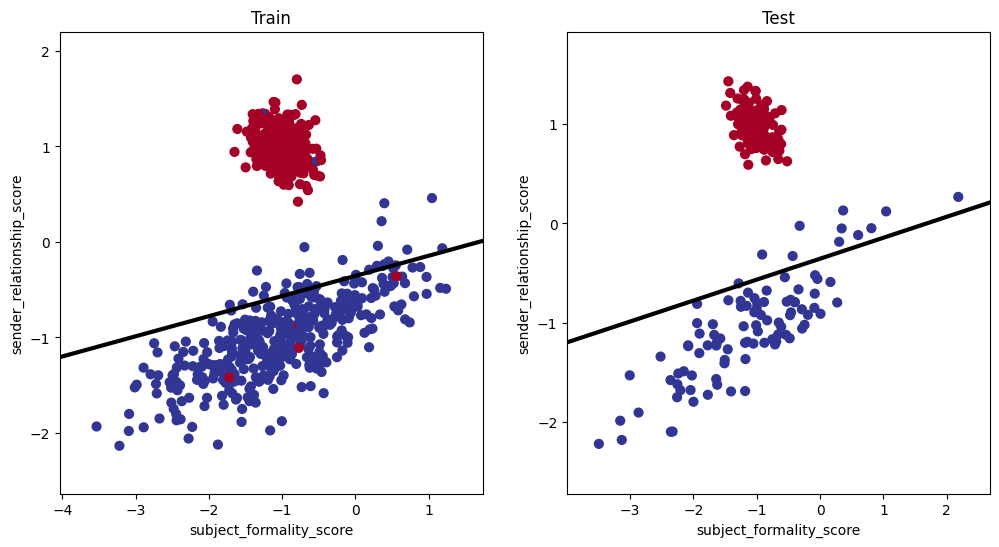

In [343]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_linear_decision_boundary(model_0, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_linear_decision_boundary(model_0, X_test, y_test)

plt.show()

In [344]:
# Data: https://github.com/atilsamancioglu/DeepLearningBootcamp/blob/main/08-seismic_activity_svm.csv

df = pd.read_csv("08-seismic_activity_svm.csv")
print(df.shape)
df.head()

(400, 3)


,underground_wave_energy,vibration_axis_variation,seismic_event_detected
0,9.539392,-3.000000,0
1,9.558241,-2.939394,0
2,9.576669,-2.878788,0
3,9.594678,-2.818182,0
4,9.612272,-2.757576,0


In [345]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   underground_wave_energy   400 non-null    float64
 1   vibration_axis_variation  400 non-null    float64
 2   seismic_event_detected    400 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 9.5 KB


In [346]:
df['seismic_event_detected'].value_counts()

,count
seismic_event_detected,
0,200
1,200


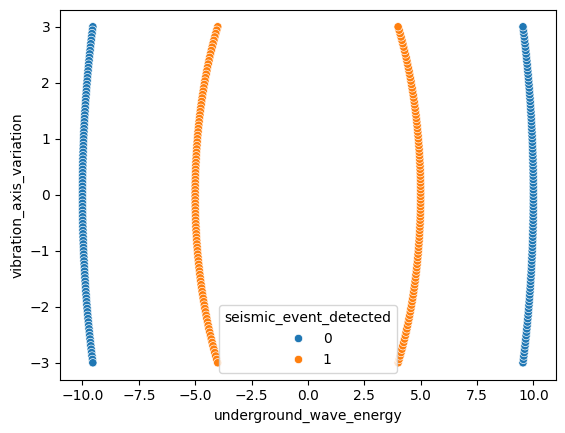

In [347]:
sns.scatterplot(data=df, x="underground_wave_energy", y="vibration_axis_variation", hue="seismic_event_detected")
plt.show()

In [348]:
# bağımlı (y) ve bağımsız (X) değişken

X = df.drop("seismic_event_detected", axis = 1).values
y = df["seismic_event_detected"].values

In [349]:
# train-test ayrmı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [350]:
len(X_train), len(X_test), len(y_train), len(y_test)

(320, 80, 320, 80)

In [351]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

In [352]:
print(X_train.shape)
print(X_train.ndim)

torch.Size([320, 2])
2


In [353]:
print(y_train.shape)
print(y_train.dim())

torch.Size([320])
1


In [354]:
y_train = y_train.unsqueeze(1)
y_test = y_test.unsqueeze(1)

In [355]:
print(y_train.shape)
print(y_train.dim())

torch.Size([320, 1])
2


In [356]:
class ClassificationNonLinearModel(nn.Module):
  def __init__(self):
    super().__init__()

    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)
    self.relu = nn.ReLU() # -> ReLU aktivasyon fonksiyonunu ekle

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    # Katmanlar arasına ReLU ekle
    return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))

In [357]:
# Şu şekilde de yazılabilir
# def forward(self, x):
    # Katmanlar arasına ReLU ekle
    # x = self.layer_1(x)
    # x = self.relu(x)
    # x = self.layer_2(x)
    # x = self.relu(x)
    # x = self.layer_3(x)
    # return x

In [358]:
model = ClassificationNonLinearModel()

In [359]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(params = model.parameters(), lr = 0.001) # SGD ve Adam ile deneyin, farkı göreceksiniz.
# optimizer = torch.optim.SGD(params = model.parameters(), lr = 0.001)

In [360]:
torch.manual_seed(42)

epochs = 500

for epoch in range(epochs):
  # Eğitim
  # Forward propagation
  y_logits = model(X_train)
  y_pred = torch.round(torch.sigmoid(y_logits))

  # loss ve acc hesapla
  loss = loss_fn(y_logits, y_train)
  acc = calculate_accuracy(y_test = y_train, y_pred = y_pred)

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Test
  model.eval()

  with torch.inference_mode():
    # Forward propagation
    test_logits = model(X_test)
    test_pred = torch.round(torch.sigmoid(test_logits))

    # loss ve acc hesapla
    test_loss = loss_fn(test_logits, y_test)
    test_acc = calculate_accuracy(y_test = y_test, y_pred = test_pred)

  if epoch % 50 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.68715, Accuracy: 57.81% | Test loss: 0.68227, Test acc: 58.75%
Epoch: 50 | Loss: 0.61604, Accuracy: 57.50% | Test loss: 0.57309, Test acc: 67.50%
Epoch: 100 | Loss: 0.56989, Accuracy: 58.13% | Test loss: 0.53181, Test acc: 65.00%
Epoch: 150 | Loss: 0.50507, Accuracy: 70.31% | Test loss: 0.48124, Test acc: 71.25%
Epoch: 200 | Loss: 0.41347, Accuracy: 86.25% | Test loss: 0.40966, Test acc: 88.75%
Epoch: 250 | Loss: 0.30355, Accuracy: 99.69% | Test loss: 0.29827, Test acc: 100.00%
Epoch: 300 | Loss: 0.20455, Accuracy: 100.00% | Test loss: 0.19371, Test acc: 100.00%
Epoch: 350 | Loss: 0.12971, Accuracy: 100.00% | Test loss: 0.12209, Test acc: 100.00%
Epoch: 400 | Loss: 0.08212, Accuracy: 100.00% | Test loss: 0.07696, Test acc: 100.00%
Epoch: 450 | Loss: 0.05380, Accuracy: 100.00% | Test loss: 0.04980, Test acc: 100.00%


In [361]:
def plot_nonlinear_decision_boundary(model, X, y):

    # Grid alanını tanımla (tüm veri aralığını kapsasın)
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    # Grid'i modele sokmak için tensor'a çevir
    grid_points = torch.tensor(
        np.c_[xx.ravel(), yy.ravel()],
        dtype=torch.float32
    )

    # Tahmin al
    model.eval()
    with torch.inference_mode():
        logits = model(grid_points)
        preds = torch.sigmoid(logits).numpy().reshape(xx.shape)  # probability map

    # Decision boundary çizimi (0.5 threshold)
    plt.contourf(xx, yy, preds, cmap=plt.cm.RdYlBu, alpha=0.7)

    # Gerçek noktalar
    plt.scatter(X[:,0], X[:,1], c=y.squeeze(), cmap=plt.cm.RdYlBu, s=30, edgecolor="k")
    plt.xlabel("underground_wave_energy")
    plt.ylabel("vibration_axis_variation")
    plt.title("Non-linear Decision Boundary")

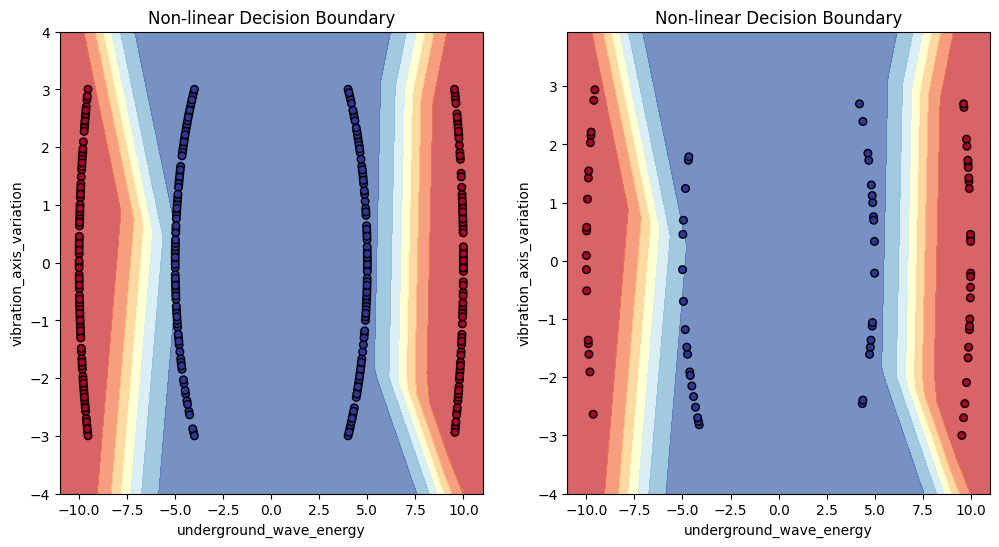

In [362]:
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.title("Train")
plot_nonlinear_decision_boundary(model, X_train, y_train)

plt.subplot(1, 2, 2)
plt.title("Test")
plot_nonlinear_decision_boundary(model, X_test, y_test)

plt.show()

Notebook'u inceledim. İşte mantığı anlatan sonuç yazısı:

---

## Sonuç

Bu çalışmada yapay sinir ağlarında **doğrusal (lineer)** ve **doğrusal olmayan (non-lineer)** modelleme arasındaki temel fark, iki farklı sınıflandırma problemi üzerinden ele alındı.

### Lineer Model — E-posta Sınıflandırması

İlk örnekte bir e-postanın iş mi kişisel mi olduğu; `subject_formality_score` ve `sender_relationship_score` değişkenleriyle tahmin edildi. Model, yalnızca `nn.Linear` katmanlarından oluşuyordu ve **aktivasyon fonksiyonu içermiyordu.**

Aktivasyon fonksiyonu olmayan ardışık lineer katmanlar, matematiksel olarak tek bir lineer dönüşüme indirgenebilir. Yani kaç katman eklenirse eklensin, model nihayetinde şu denklemi öğrenir:

```
output = W_eff · x + b_eff
```

Bu durum karar sınırının her zaman **düz bir çizgi** olacağı anlamına gelir. Veri bu yapıya uygunsa —yani iki sınıf doğrusal olarak ayrılabiliyorsa— model yeterince iyi çalışır. Karar sınırı analitik olarak da hesaplanabildiğinden, ağırlıklar birleştirilerek sınır doğrudan görselleştirilebilir.

### Non-Lineer Model — Sismik Aktivite Tespiti

İkinci örnekte, sismik aktivitenin tespit edilip edilemeyeceği `underground_wave_energy` ve `vibration_axis_variation` değişkenleriyle tahmin edildi. Bu verideki sınıflar dairesel veya iç içe geçmiş bir yapı sergiliyordu ve düz bir çizgiyle ayrılamazdı.

Bu nedenle modelin katmanları arasına **ReLU aktivasyon fonksiyonu** eklendi:

```python
return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
```

ReLU, her katmandan geçen bilgiyi doğrusal olmayan bir biçimde dönüştürür. Bu sayede model, düzlemi bükme, kıvırma ve parçalara bölme kapasitesi kazanır; karar sınırı artık düz bir çizgi değil, **verinin gerçek yapısına uyum sağlayan eğrisel bir sınır** haline gelir.

### Temel Çıkarım

| | Lineer Model | Non-Lineer Model |
|---|---|---|
| **Aktivasyon** | Yok | ReLU |
| **Karar Sınırı** | Düz çizgi | Eğrisel / karmaşık |
| **Ne zaman yeterli?** | Veriler doğrusal ayrılabilirken | Veriler iç içe veya dairesel yapıdayken |
| **Matematiksel özü** | Tek bir lineer dönüşüm | Parça parça doğrusal dönüşümlerin birleşimi |

Aktivasyon fonksiyonları, bir yapay sinir ağını gerçek anlamda "derin" kılan unsurdur. Onlar olmadan, ne kadar çok katman eklenirse eklensin model lineer kalmaya devam eder. **Aktivasyon fonksiyonları sayesinde ANN'ler, gerçek dünyadaki karmaşık ve düzensiz veri yapılarını modelleyebilir hale gelir.**